In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import os

from pythainlp.tokenize import word_tokenize
from pythainlp.tag import pos_tag
import pythainlp# Method_Precast_For_Repairing_Tunnet_Segment

# Data visualization

In [20]:
df = pd.read_csv("C:\\Users\\User\\LLM_Construction\\table\\Method_Precast_For_Repairing_Tunnel_Segment.csv")

In [148]:
df['content'].unique()

array(['10_Preventative_Measures_And_Revise_Environment_Impact',
       '11_Tunnel_SegmentA_Repair_Note',
       '12_Material_Approval_Document_from_the_Project_Office',
       '1_Guildline_For_Repair', '2_Repair_With_Cementitious_Mortar',
       '3_Repair_With_Epoxy_Resin', '4_Spalling_Edge_Repair',
       '5_Voids_And_Blowholes_Repair',
       '6_Voids_And_Blowholes_Repair_With_High_Strength_Mortar',
       '7_Materials_Data_Sheet', '8_Risk_Assessment_In_Repair_Working',
       '9_Materials_Safety_Data'], dtype=object)

In [ ]:
# import ast
# pos_tags = ast.literal_eval(df['pos_tags'][i])

In [164]:
import ast
a = 1
print(df[df['content'] == '7_Materials_Data_Sheet']['page'].iloc[a])
print(df[df['content'] == '7_Materials_Data_Sheet']['pos_tags'].iloc[a])

101
[('4', 'NLBL'), ('Bee', 'NCMN'), (' ', 'PUNC'), ('Brand', 'NCMN'), (' ', 'PUNC'), ('-', 'PUNC'), (' ', 'PUNC'), ('"The', 'NCMN'), (' ', 'PUNC'), ('Professional', 'NCMN'), ("'s", 'PUNC'), (' ', 'PUNC'), ('Choice', 'NCMN'), ('"', 'PUNC'), ('ปน', 'NCMN'), ('ตรา', 'NCMN'), ('ผึ้ง', 'NCMN'), ('"SINCE', 'NCMN'), (' ', 'PUNC'), ('1993', 'NCNM'), ('PRODUCT', 'NCMN'), (' ', 'PUNC'), ('DETAILS', 'NCMN'), ('BEE', 'NCMN'), (' ', 'PUNC'), ('BRAND', 'NCMN'), ('NO', 'NCMN'), ('.', 'PUNC'), (' ', 'PUNC'), ('124', 'NCNM'), (',', 'PUNC'), (' ', 'PUNC'), ('124', 'DCNM'), (' ', 'PUNC'), ('L', 'CMTR'), (',', 'PUNC'), (' ', 'PUNC'), ('124', 'DCNM'), (' ', 'PUNC'), ('W', 'CMTR'), (',124', 'NCMN'), (' ', 'PUNC'), ('WL', 'NCMN'), ('SKIM', 'NCMN'), (' ', 'PUNC'), ('COAT', 'NCMN'), (' ', 'PUNC'), ('MORTAR', 'NCMN'), ('TIS', 'NCMN'), (' ', 'PUNC'), ('1776', 'NCNM'), ('-', 'PUNC'), ('2542', 'NCNM'), (' ', 'PUNC'), ('TYPE', 'NCMN'), (' ', 'PUNC'), ('CO', 'NCMN'), ('4', 'NCNM'), ('RUOS', 'NCMN'), (' ', 'PUNC'), 

## 0. Graph function

- ฟังก์ชันที่จำเป็นสำหับการพล็อตกราฟ เช่า Histogram, Bar plot, Box plot เป็นต้น

In [17]:
def plot_boxplots(df, cols=None, ncols=2, showfliers=True, notch=False, whis=1.5,
                  horizontal=False, order_by_median=False):
    """
    Plot box plots for numeric columns.

    Args:
        df (pd.DataFrame): your data
        cols (list[str] | None): which numeric columns to plot;
                                 if None, auto-detect numeric columns
        ncols (int): number of subplots per row
        showfliers (bool): show outlier points
        notch (bool): draw a notch to display the median CI
        whis (float | tuple): IQR whisker length or (lo, hi) percentiles (e.g., (5,95))
        horizontal (bool): if True, draw horizontal boxes
        order_by_median (bool): if True, sort columns by median before plotting
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Pick numeric columns if not provided
    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if not cols:
        raise ValueError("No numeric columns to plot.")

    # Optionally sort by column medians (ascending)
    if order_by_median:
        med = df[cols].median(numeric_only=True).sort_values()
        cols = med.index.tolist()

    nrows = -(-len(cols) // ncols)  # ceiling division
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6*ncols, 4*nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(cols):
        ax = axes[i]
        data = df[col].dropna()

        # seaborn handles nicer stats & fliers; orientation via x/y
        if horizontal:
            sns.boxplot(x=data, ax=ax, showfliers=showfliers, notch=notch, whis=whis)
            ax.set_xlabel(col)
            ax.set_ylabel("")
        else:
            sns.boxplot(y=data, ax=ax, showfliers=showfliers, notch=notch, whis=whis)
            ax.set_ylabel(col)
            ax.set_xlabel("")

        ax.set_title(f"{col} box plot")
        ax.grid(axis="y" if not horizontal else "x", linestyle="--", alpha=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Remove any unused axes
    for j in range(len(cols), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


In [18]:
def plot_numeric_distributions(
    df,
    cols=None,
    bins=30,
    ncols=2,
    kde=True,
    show_stats=True,          # <- new: show mean/var/std box
    ddof=1,                   # <- new: variance/SD degrees of freedom (1 = sample, 0 = population)
    stats_loc=(0.98, 0.98),   # <- new: box location in axes coords (x,y), 0..1
):
    """
    Plot histogram distributions for numeric columns, with robust column handling
    and per-plot statistics overlays (mean line, mean/variance/std box).

    Parameters
    ----------
    df : pandas.DataFrame
    cols : list[str] | None
        Which columns to plot; default = all numeric columns in df.
    bins : int
        Histogram bins.
    ncols : int
        Number of subplot columns.
    kde : bool
        Whether to draw a KDE curve (seaborn).
    show_stats : bool
        If True, annotate each chart with mean/variance/std and draw a mean line.
    ddof : int
        Delta degrees of freedom for var/std: 1 = sample, 0 = population.
    stats_loc : tuple[float, float]
        (x, y) in axes coordinates for the stats box (e.g., (0.02, 0.98) for top-left).
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from pandas.api.types import is_numeric_dtype

    # 1) Decide candidate columns
    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()
    else:
        cols = list(cols)

    # 2) Split into present vs. missing
    present = [c for c in cols if c in df.columns]
    missing = sorted(set(cols) - set(present))

    # 3) Keep only numeric among present
    non_numeric = [c for c in present if not is_numeric_dtype(df[c])]
    numeric_present = [c for c in present if is_numeric_dtype(df[c])]

    # 4) Warn helpfully
    if missing:
        print(f"[plot_numeric_distributions] Skipped missing columns: {missing}")
    if non_numeric:
        print(f"[plot_numeric_distributions] Skipped non-numeric columns: {non_numeric}")

    if not numeric_present:
        raise ValueError("No valid numeric columns to plot after filtering (all missing or non-numeric).")

    # 5) Make grid
    ncols = max(1, int(ncols))
    n = len(numeric_present)
    nrows = -(-n // ncols)  # ceil division
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6*ncols, 4*nrows))
    axes = np.atleast_1d(axes).ravel()

    # 6) Plot each numeric column
    for i, col in enumerate(numeric_present):
        ax = axes[i]
        data = df[col].dropna().astype(float)

        # histogram (+ optional KDE)
        sns.histplot(data, bins=bins, kde=kde, ax=ax, edgecolor="black")
        ax.set_title(f"{col} distribution")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if show_stats and len(data):
            mean = float(data.mean())
            var = float(data.var(ddof=ddof))
            std = float(data.std(ddof=ddof))

            # Mean line
            ax.axvline(mean, linestyle="--", linewidth=1.5)

            # Text box with stats
            stats_text = (
                f"mean = {mean:,.4g}\n"
                f"var  = {var:,.4g} (ddof={ddof})\n"
                f"sd   = {std:,.4g}"
            )
            ax.text(
                stats_loc[0], stats_loc[1], stats_text,
                transform=ax.transAxes,
                ha="right", va="top",
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.35", alpha=0.15)
            )

    # 7) Remove unused subplots
    for j in range(len(numeric_present), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


In [19]:
# categorical bar chart

def plot_bar_charts_grid(df, cols, top_n=None, normalize=False, ncols=3):
    """
    Grid of bar charts for categorical columns.

    Args:
        df (pd.DataFrame): your data
        cols (list[str]): columns to plot
        top_n (int|None): show only top N most frequent categories
        normalize (bool): if True, show percentages instead of raw counts
        ncols (int): number of charts per row
    """
    import matplotlib.pyplot as plt
    from matplotlib.ticker import FuncFormatter

    def k_format(x, _):
        if x >= 1_000_000: return f"{int(x/1_000_000)}M"
        if x >= 1_000:     return f"{int(x/1_000)}k"
        return str(int(x))

    nrows = -(-len(cols) // ncols)  # ceiling division
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 3*nrows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        counts = (
            df[col]
            .astype("category")
            .cat.add_categories(["<NaN>"])
            .fillna("<NaN>")
            .value_counts(dropna=False)
            .sort_values(ascending=False)
        )
        if top_n:
            counts = counts.iloc[:top_n]

        vals = (counts / counts.sum() * 100.0).round(1) if normalize else counts

        vals.plot(kind="bar", ax=ax, color="skyblue", edgecolor="black")

        ax.set_title(f"{col} distribution")
        ax.set_xlabel("")
        ax.set_ylabel("Percent" if normalize else "Count")
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        ax.tick_params(axis="x", labelrotation=30)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if not normalize:
            ax.yaxis.set_major_formatter(FuncFormatter(k_format))

        # annotate bars
        for rect, v in zip(ax.patches, vals.values):
            h = rect.get_height()
            label = f"{v:.1f}%" if normalize else f"{int(h)}"
            ax.annotate(label,
                        (rect.get_x() + rect.get_width()/2, h),
                        ha="center", va="bottom",
                        fontsize=0.5, xytext=(0, 3), textcoords="offset points")

    # remove unused subplots if cols not multiple of ncols
    for j in range(len(cols), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()



## 1. tokenization

In [57]:
# count token per content column
token_counts_by_content = df.groupby('content')['tokens_count'].sum().reset_index().sort_values(by='tokens_count', ascending=False)
token_counts_by_content

,content,tokens_count
9,7_Materials_Data_Sheet,40253
11,9_Materials_Safety_Data,4192
2,12_Material_Approval_Document_from_the_Project...,2064
5,3_Repair_With_Epoxy_Resin,1596
3,1_Guildline_For_Repair,1533
0,10_Preventative_Measures_And_Revise_Environmen...,1483
6,4_Spalling_Edge_Repair,1417
10,8_Risk_Assessment_In_Repair_Working,1197
4,2_Repair_With_Cementitious_Mortar,1038
7,5_Voids_And_Blowholes_Repair,983


In [ ]:
# content_name = [
#     "1_Guildline_For_Repair",
#     "2_Repair_With_Cementitious_Mortar",
#     "3_Repair_With_Epoxy_Resin",
#     "4_Spalling_Edge_Repair",
#     "5_Voids_And_Blowholes_Repair",
#     "6_Voids_And_Blowholes_Repair_With_High_Strength_Mortar",
#     "7_Materials_Data_Sheet",
#     "8_Risk_Assessment_In_Repair_Working",
#     "9_Materials_Safety_Data",
#     "10_Preventative_Measures_And_Revise_Environment_Impact",
#     "11_Tunnel_SegmentA_Repair_Note",
#     "12_Material_Approval_Document_from_the_Project_Office"
# ]

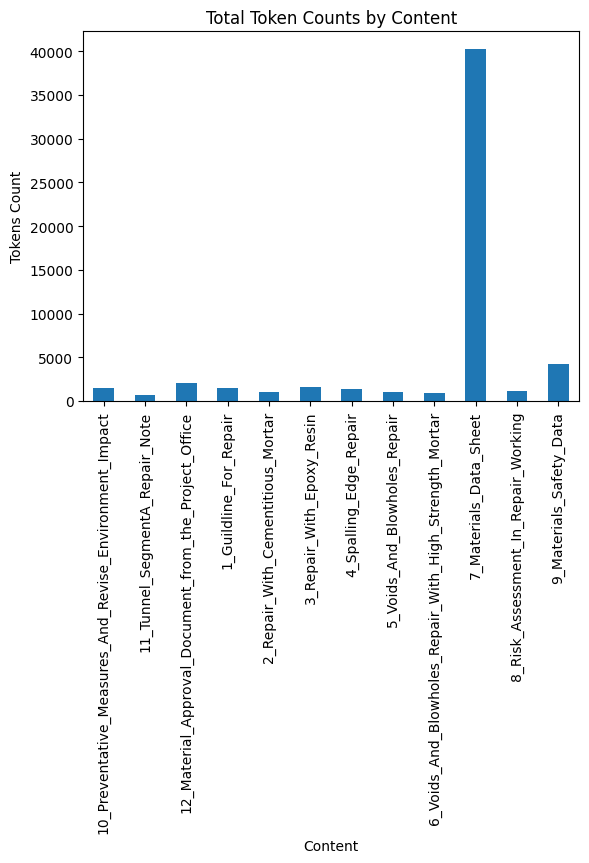

In [42]:
# bar chart
token_counts_by_content.plot(kind='bar', x='content', y='tokens_count', legend=False)
plt.title('Total Token Counts by Content')
plt.xlabel('Content')
plt.ylabel('Tokens Count')
plt.show()

<Figure size 2000x2000 with 0 Axes>

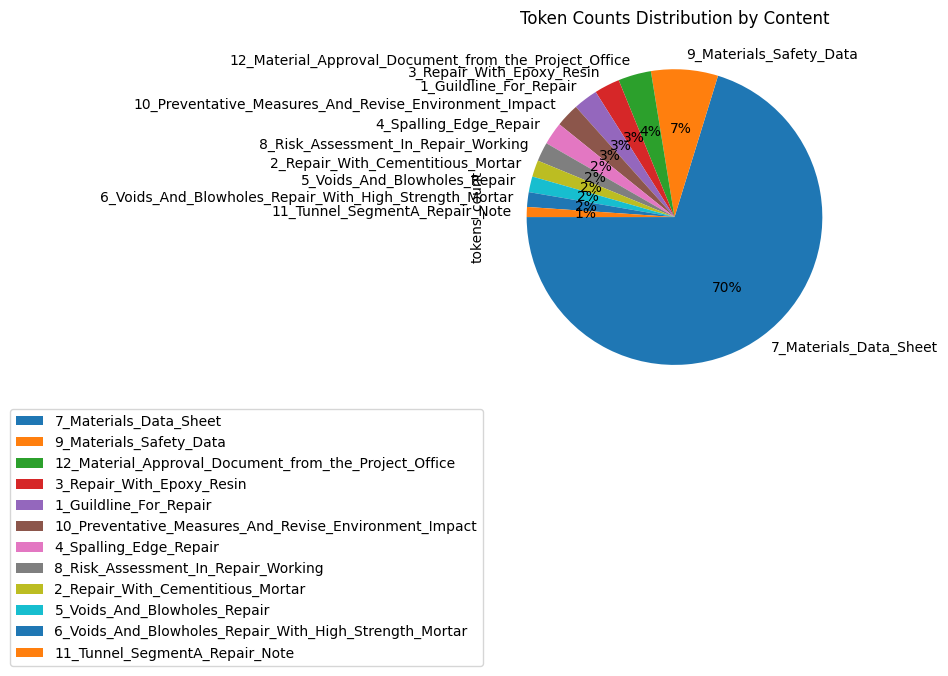

In [136]:
# pie chart
plt.figure(figsize=(20, 20))
token_counts_by_content.set_index('content').sort_values(by='tokens_count', ascending=False).plot.pie(y='tokens_count', autopct='%1.0f%%', startangle=180)
plt.legend(loc='upper right', bbox_to_anchor=(0, 0))
plt.title('Token Counts Distribution by Content')
plt.show()

## 2. unique word

In [70]:
POS_ABBREVIATIONS = {
    "NPRP" : 0,
    "NCNM" : 0,
    "NONM" : 0,
    "NLBL" : 0,
    "NCMN" : 0,
    "NTTL" : 0,
    "PPRS" : 0,
    "PDMN" : 0,
    "PNTR" : 0,
    "PREL" : 0,
    "VACT" : 0,
    "VSTA" : 0,
    "VATT" : 0,
    "XVBM" : 0,
    "XVAM" : 0,
    "XVMM" : 0,
    "XVBB" : 0,
    "XVAE" : 0,
    "DDAN" : 0,
    "DDAC" : 0,
    "DDBQ" : 0,
    "DDAQ" : 0,
    "DIAC" : 0,
    "DIBQ" : 0,
    "DIAQ" : 0,
    "DCNM" : 0,
    "DONM" : 0,
    "ADVN" : 0,
    "ADVI" : 0,
    "ADVP" : 0,
    "ADVS" : 0,
    "CNIT" : 0,
    "CLTV" : 0,
    "CMTR" : 0,
    "CFQC" : 0,
    "CVBL" : 0,
    "JCRG" : 0,
    "JCMP" : 0,
    "JSBR" : 0,
    "RPRE" : 0,
    "INT" : 0,
    "FIXN" : 0,
    "FIXV" : 0,
    "EAFF" : 0,
    "EITT" : 0,
    "NEG" : 0,
    "PUNC" : 0
}

print(len(POS_ABBREVIATIONS))

47


In [71]:
tag = pd.DataFrame(columns=POS_ABBREVIATIONS.keys())
tag

,NPRP,NCNM,NONM,NLBL,NCMN,NTTL,PPRS,PDMN,PNTR,PREL,...,JCMP,JSBR,RPRE,INT,FIXN,FIXV,EAFF,EITT,NEG,PUNC


In [102]:
POS_ABBREVIATIONS = {
    'content' : [],
    "NPRP" : 0,
    "NCNM" : 0,
    "NONM" : 0,
    "NLBL" : 0,
    "NCMN" : 0,
    "NTTL" : 0,
    "PPRS" : 0,
    "PDMN" : 0,
    "PNTR" : 0,
    "PREL" : 0,
    "VACT" : 0,
    "VSTA" : 0,
    "VATT" : 0,
    "XVBM" : 0,
    "XVAM" : 0,
    "XVMM" : 0,
    "XVBB" : 0,
    "XVAE" : 0,
    "DDAN" : 0,
    "DDAC" : 0,
    "DDBQ" : 0,
    "DDAQ" : 0,
    "DIAC" : 0,
    "DIBQ" : 0,
    "DIAQ" : 0,
    "DCNM" : 0,
    "DONM" : 0,
    "ADVN" : 0,
    "ADVI" : 0,
    "ADVP" : 0,
    "ADVS" : 0,
    "CNIT" : 0,
    "CLTV" : 0,
    "CMTR" : 0,
    "CFQC" : 0,
    "CVBL" : 0,
    "JCRG" : 0,
    "JCMP" : 0,
    "JSBR" : 0,
    "RPRE" : 0,
    "INT" : 0,
    "FIXN" : 0,
    "FIXV" : 0,
    "EAFF" : 0,
    "EITT" : 0,
    "NEG" : 0,
    "PUNC" : 0
}

print(len(POS_ABBREVIATIONS))

48


In [105]:
tag_per_content = pd.DataFrame(columns=POS_ABBREVIATIONS.keys())
tag_per_content
import ast
# conut tag per content
for i in range(len(df)):
    content = df['content'][i]
    pos_tags = ast.literal_eval(df['pos_tags'][i])
    tag_count = POS_ABBREVIATIONS.copy()
    tag_count['content'] = content
    for word, pos in pos_tags:
        if pos in tag_count:
            tag_count[pos] += 1
    tag_per_content = pd.concat([tag_per_content, pd.DataFrame([tag_count])], ignore_index=True)

In [110]:
tag_counts_per_content = tag_per_content.groupby('content').sum()
tag_counts_per_content.head()

,NPRP,NCNM,NONM,NLBL,NCMN,NTTL,PPRS,PDMN,PNTR,PREL,...,JCMP,JSBR,RPRE,INT,FIXN,FIXV,EAFF,EITT,NEG,PUNC
content,,,,,,,,,,,,,,,,,,,,,
10_Preventative_Measures_And_Revise_Environment_Impact,10,35,0,0,578,0,9,0,0,27,...,0,66,72,0,13,2,0,0,9,332
11_Tunnel_SegmentA_Repair_Note,3,5,0,0,349,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,268
12_Material_Approval_Document_from_the_Project_Office,39,114,0,7,710,0,0,0,5,59,...,0,32,91,0,2,0,0,0,4,586
1_Guildline_For_Repair,15,72,0,4,712,0,0,0,0,6,...,0,7,16,0,4,0,0,0,3,523
2_Repair_With_Cementitious_Mortar,14,43,0,1,408,0,0,0,0,17,...,1,15,28,0,13,0,0,0,1,338


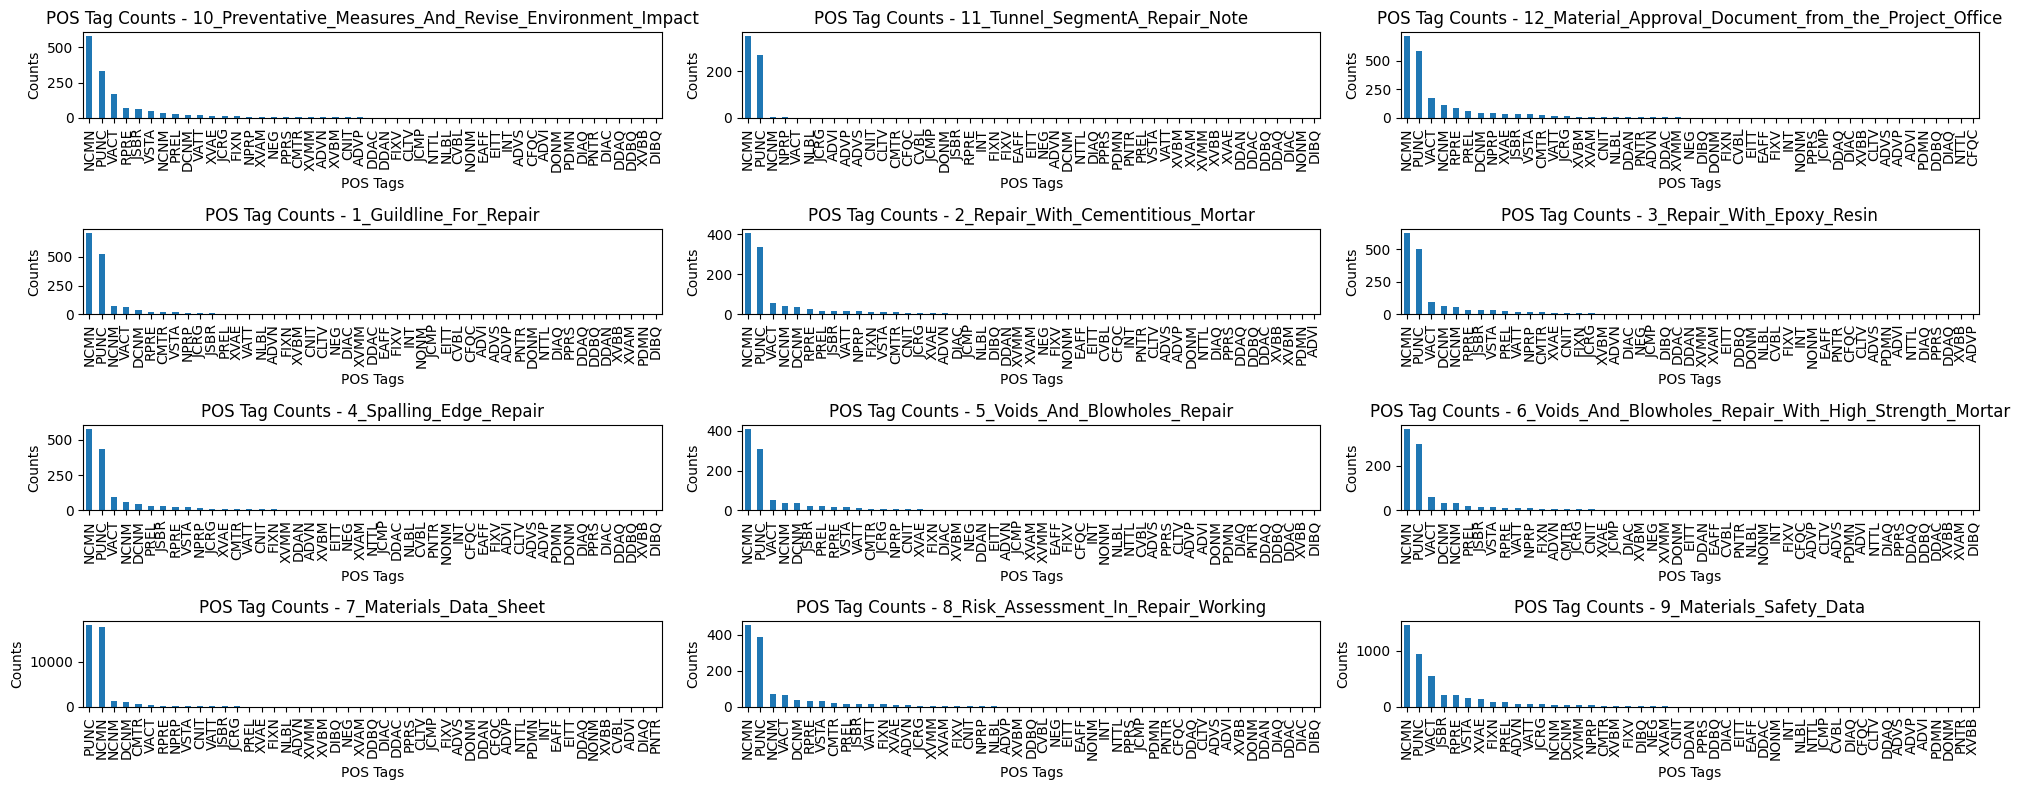

In [123]:
# plot tag_counts_per_content (12 contents 12 graphs subplot)
plt.figure(figsize=(20, 8))
for i, content in enumerate(tag_counts_per_content.index):
    plt.subplot(4, 3, i+1)
    tag_counts_per_content.loc[content].sort_values(ascending=False).plot(kind='bar', legend=False)
    plt.title(f'POS Tag Counts - {content}')
    plt.xlabel('POS Tags')
    plt.ylabel('Counts')
    plt.tight_layout()
plt.show()

In [85]:
# import ast
# result = ast.literal_eval(df['pos_tags'][0]) 

In [86]:
import ast
for i in range(len(df)):
    pos_tags = ast.literal_eval(df['pos_tags'][i])
    tag_count = POS_ABBREVIATIONS.copy()
    for word, tag_label in pos_tags:
        if tag_label in tag_count:
            tag_count[tag_label] += 1
    for key in tag_count:
        tag.at[i, key] = tag_count[key]

In [91]:
tag

,NPRP,NCNM,NONM,NLBL,NCMN,NTTL,PPRS,PDMN,PNTR,PREL,...,JCMP,JSBR,RPRE,INT,FIXN,FIXV,EAFF,EITT,NEG,PUNC
0,2,2,0,0,36,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,28
1,2,10,0,0,144,0,1,0,0,7,...,0,10,25,0,1,1,0,0,1,97
2,2,7,0,0,145,0,4,0,0,8,...,0,26,17,0,5,0,0,0,4,65
3,2,8,0,0,115,0,0,0,0,6,...,0,11,17,0,3,1,0,0,1,80
4,2,8,0,0,138,0,4,0,0,6,...,0,19,13,0,4,0,0,0,3,62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,3,4,0,0,169,0,1,0,0,9,...,0,31,23,0,10,1,0,0,1,110
143,4,4,0,0,161,0,0,0,0,9,...,0,23,25,0,11,1,0,0,1,105
144,4,4,0,0,139,0,0,0,0,8,...,0,19,22,0,8,0,0,0,0,89
145,4,4,0,0,177,0,0,0,0,11,...,0,22,27,0,10,1,0,0,0,116


In [96]:
tagV2 = tag.drop(['NCMN', 'PUNC'], axis=1)
tagV2

,NPRP,NCNM,NONM,NLBL,NTTL,PPRS,PDMN,PNTR,PREL,VACT,...,JCRG,JCMP,JSBR,RPRE,INT,FIXN,FIXV,EAFF,EITT,NEG
0,2,2,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0
1,2,10,0,0,0,1,0,0,7,45,...,3,0,10,25,0,1,1,0,0,1
2,2,7,0,0,0,4,0,0,8,49,...,4,0,26,17,0,5,0,0,0,4
3,2,8,0,0,0,0,0,0,6,35,...,4,0,11,17,0,3,1,0,0,1
4,2,8,0,0,0,4,0,0,6,38,...,3,0,19,13,0,4,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,3,4,0,0,0,1,0,0,9,72,...,5,0,31,23,0,10,1,0,0,1
143,4,4,0,0,0,0,0,0,9,68,...,6,0,23,25,0,11,1,0,0,1
144,4,4,0,0,0,0,0,0,8,51,...,6,0,19,22,0,8,0,0,0,0
145,4,4,0,0,0,0,0,0,11,70,...,9,0,22,27,0,10,1,0,0,0


In [101]:
tag.sum().sort_values(ascending=False)

NCMN    24452
PUNC    23117
NCNM     1922
VACT     1689
DCNM     1496
CMTR      715
RPRE      664
JSBR      510
VSTA      460
PREL      350
XVAE      291
NPRP      284
VATT      241
FIXN      205
JCRG      193
CNIT      129
ADVN      124
XVMM       80
XVBM       59
NLBL       50
XVAM       44
NEG        43
DIBQ       28
DIAC       23
DDAN       20
DDAC       20
FIXV       16
PPRS       15
DDBQ       13
JCMP       12
CLTV        9
DONM        8
ADVP        6
EITT        5
PNTR        5
ADVS        2
NTTL        2
EAFF        1
PDMN        1
CFQC        1
NONM        0
INT         0
DIAQ        0
DDAQ        0
ADVI        0
XVBB        0
CVBL        0
dtype: object

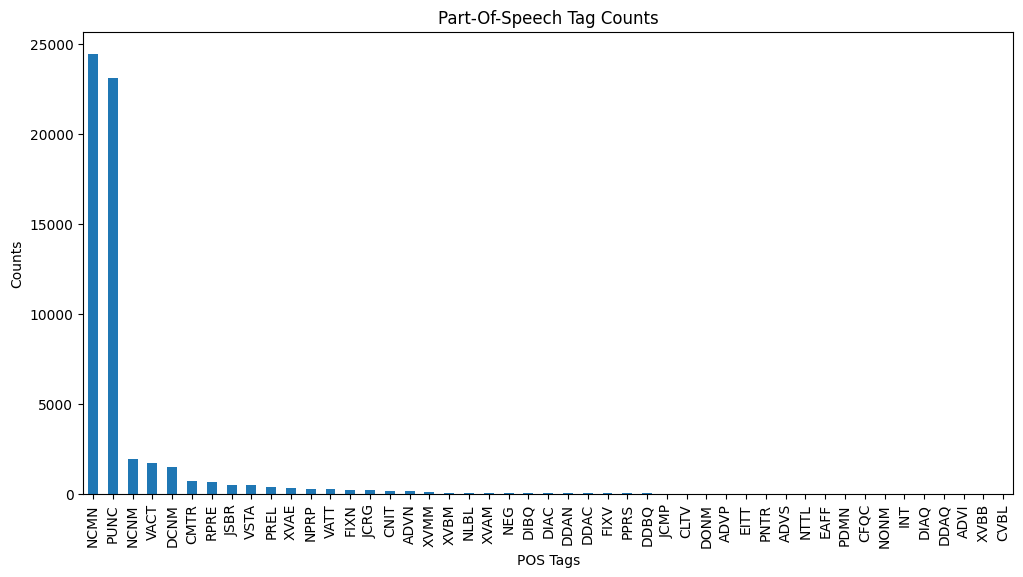

In [125]:
tag.sum().head()
# plot the results (remove 'NCMN', 'PUNC')
plt.figure(figsize=(12, 6))
tag.sum().sort_values(ascending=False).plot(kind='bar', legend=False)
plt.title('Part-Of-Speech Tag Counts')
plt.xlabel('POS Tags')
plt.ylabel('Counts')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_21916\20031087.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tag.sum().plot.pie(autopct='%1.1f%%', startangle=140)


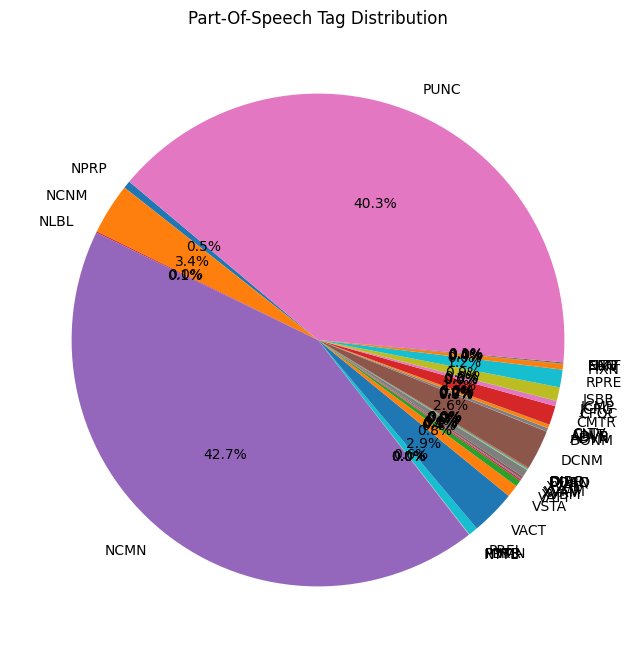

In [100]:
# pie plot
plt.figure(figsize=(8, 8))
tag.sum().plot.pie(autopct='%1.1f%%', startangle=140)
plt.title('Part-Of-Speech Tag Distribution')
plt.show()

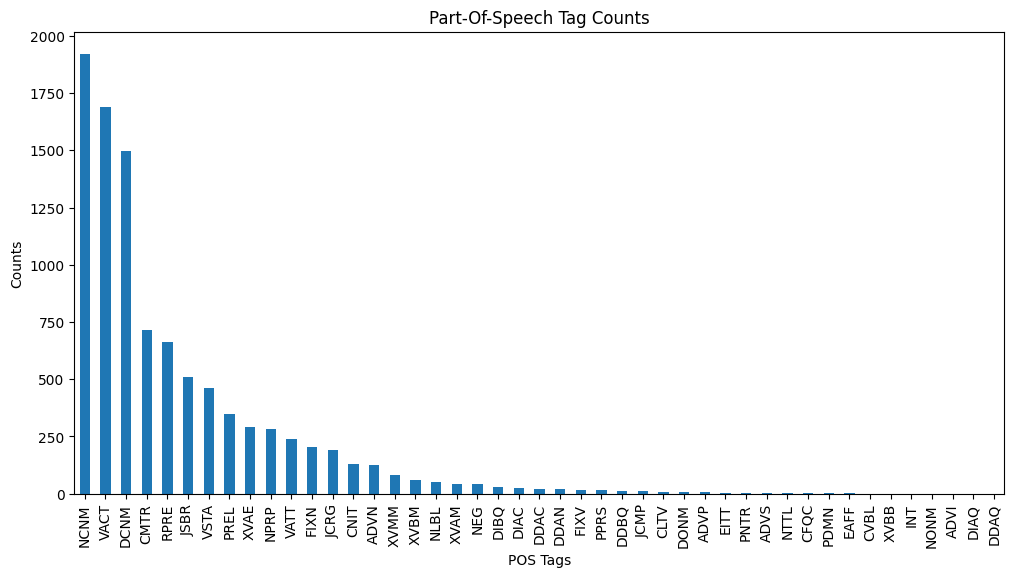

In [126]:
tagV2.sum().head()
# plot the results (remove 'NCMN', 'PUNC')
plt.figure(figsize=(12, 6))
tagV2.sum().sort_values(ascending=False).plot(kind='bar', legend=False)
plt.title('Part-Of-Speech Tag Counts')
plt.xlabel('POS Tags')
plt.ylabel('Counts')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_21916\1267593910.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tagV2.sum().plot.pie(autopct='%1.1f%%', startangle=140)


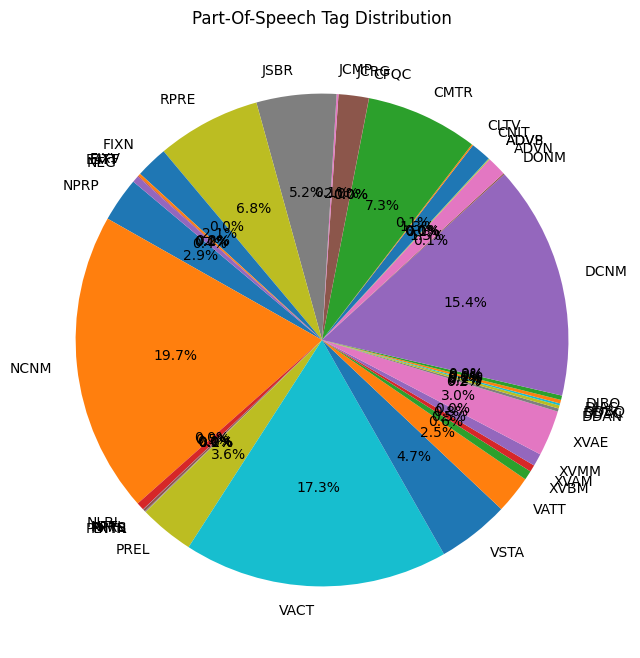

In [98]:
# pie plot
plt.figure(figsize=(8, 8))
tagV2.sum().plot.pie(autopct='%1.1f%%', startangle=140)
plt.title('Part-Of-Speech Tag Distribution')
plt.show()

## 3. language count

In [140]:
# sum language count per content
df_lang = df.groupby('content')[['th_token_count', 'en_token_count']].sum().reset_index().sort_values(by='th_token_count', ascending=False)
df_lang

,content,th_token_count,en_token_count
9,7_Materials_Data_Sheet,20819,19426
11,9_Materials_Safety_Data,3787,405
2,12_Material_Approval_Document_from_the_Project...,1940,123
0,10_Preventative_Measures_And_Revise_Environmen...,1268,215
5,3_Repair_With_Epoxy_Resin,1162,434
6,4_Spalling_Edge_Repair,1021,396
10,8_Risk_Assessment_In_Repair_Working,898,298
3,1_Guildline_For_Repair,890,643
4,2_Repair_With_Cementitious_Mortar,750,288
7,5_Voids_And_Blowholes_Repair,711,272


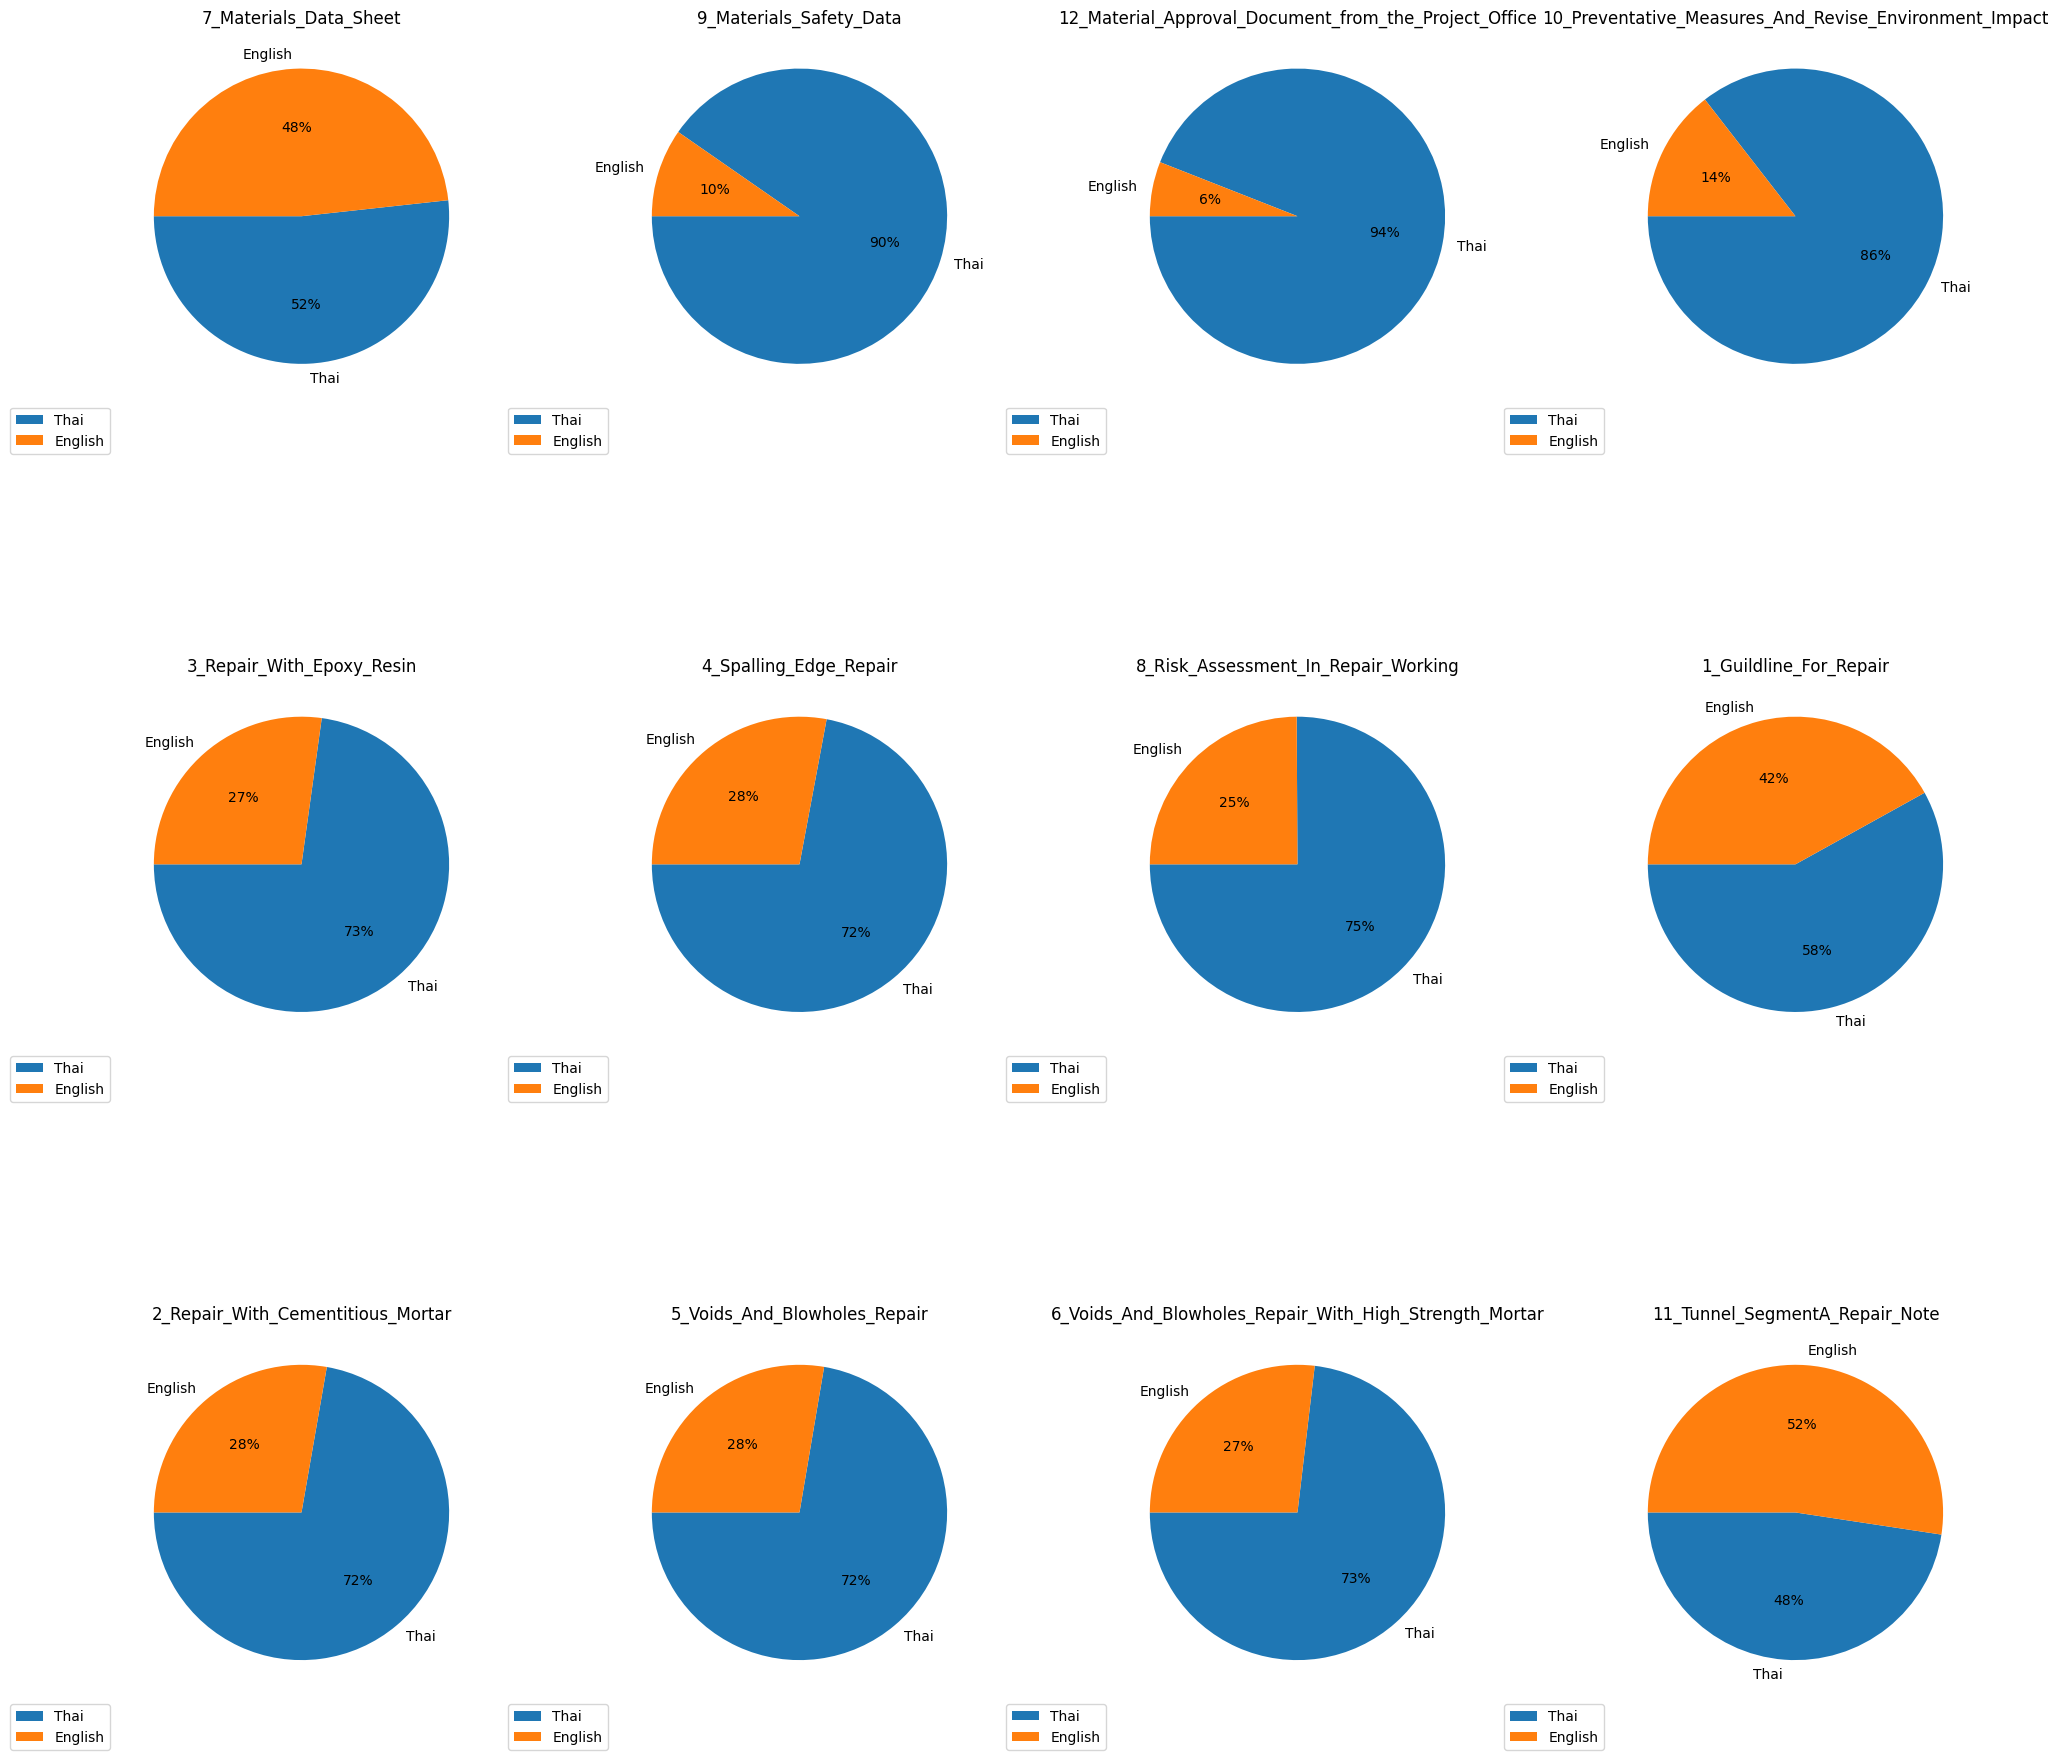

In [147]:
# plot 12 pie charts for language distribution per content
plt.figure(figsize=(20, 20))

for i, content in enumerate(df_lang['content'].unique()):
    plt.subplot(3, 4, i+1)
    data = df_lang[df_lang['content'] == content][['th_token_count', 'en_token_count']].iloc[0]#
    plt.pie(data, labels=['Thai', 'English'], autopct='%1.0f%%', startangle=180, )
    plt.legend(loc='upper right', bbox_to_anchor=(0, 0))
    plt.title(content)

plt.tight_layout()
plt.show()